# Mushroom Edibility — Model Building

Train and compare 7 classification models on a fully one-hot-encoded feature space, plus a tuned best performer.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import roc_curve, auc

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_confusion_matrix,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/mushrooms_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (8124, 96)


,class,cap_shape_c,cap_shape_f,cap_shape_k,cap_shape_s,cap_shape_x,cap_surface_g,cap_surface_s,cap_surface_y,cap_color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,0,0,0,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


## 2. Train / Test Split + Scaling

Features are all 0/1 dummies, so scaling is mostly cosmetic, but we keep `StandardScaler` for the distance-based models.

In [3]:
X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train poisonous-rate: {y_train.mean():.3f}, Test: {y_test.mean():.3f}")

Train: (6499, 95), Test: (1625, 95)
Train poisonous-rate: 0.482, Test: 0.482


## 3. Model 1 — Logistic Regression


  Logistic Regression
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000


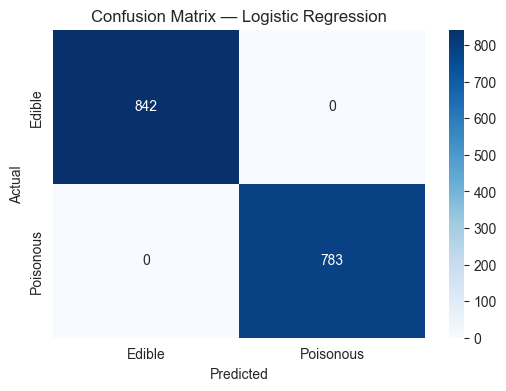

In [4]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression"); plt.show()

## 4. Model 2 — Decision Tree


  Decision Tree
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000


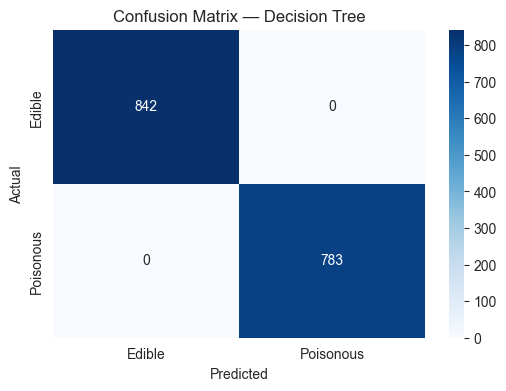

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree"); plt.show()

## 5. Model 3 — Random Forest


  Random Forest
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000


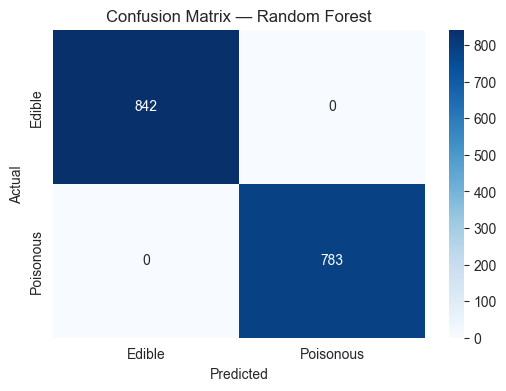

In [6]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); plt.show()

## 6. Model 4 — KNN (with K optimization)

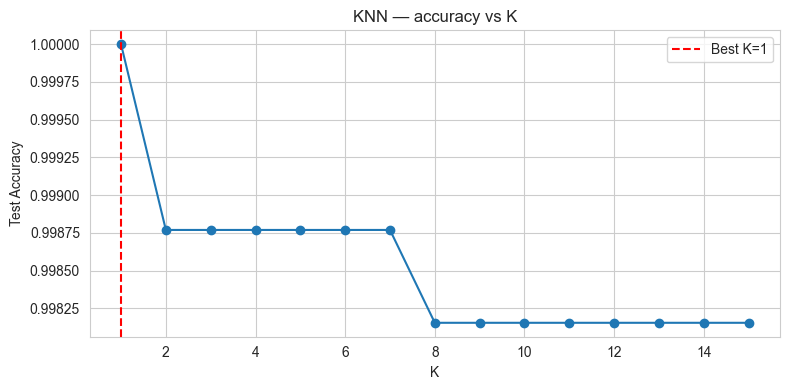


  KNN (K=1)
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000


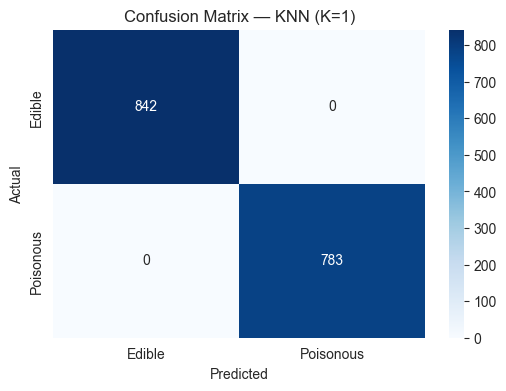

In [7]:
ks = list(range(1, 16))
acc = []
for k in ks:
    kk = KNeighborsClassifier(n_neighbors=k)
    kk.fit(X_train_s, y_train)
    acc.append(kk.score(X_test_s, y_test))

best_k = ks[int(np.argmax(acc))]
plt.figure(figsize=(8, 4))
plt.plot(ks, acc, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test Accuracy"); plt.title("KNN — accuracy vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})"); plt.show()

## 7. Model 5 — SVM


  SVM
  Accuracy    : 0.9988
  Precision   : 1.0000
  Recall      : 0.9974
  F1 Score    : 0.9987


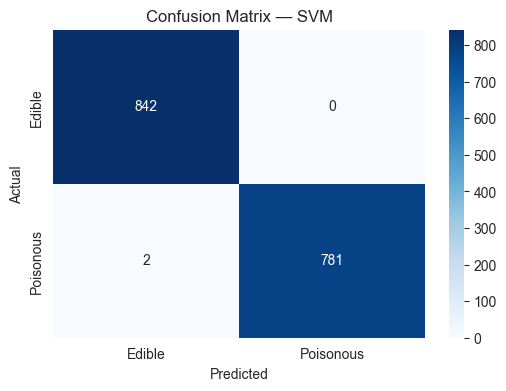

In [8]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)
m_svm = evaluate_model("SVM", y_test, pred_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM"); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.9988
  Precision   : 1.0000
  Recall      : 0.9974
  F1 Score    : 0.9987


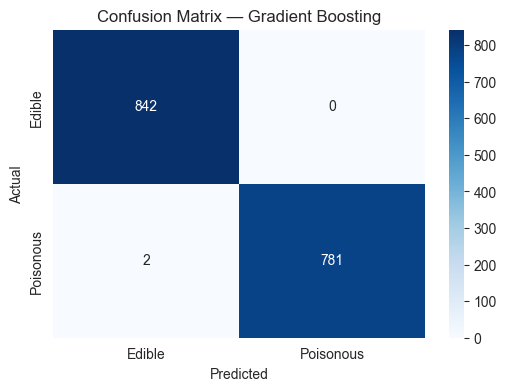

In [9]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); plt.show()

## 9. Model 7 — Naive Bayes (Bernoulli — fits 0/1 dummies)


  Naive Bayes (Bernoulli)
  Accuracy    : 0.9286
  Precision   : 0.9883
  Recall      : 0.8621
  F1 Score    : 0.9209


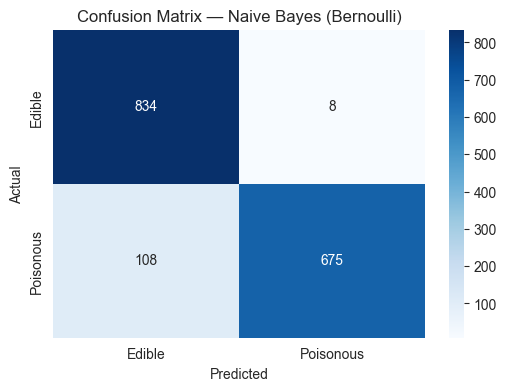

In [10]:
nb = BernoulliNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
m_nb = evaluate_model("Naive Bayes (Bernoulli)", y_test, pred_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes (Bernoulli)"); plt.show()

## 10. Feature Importance (tree-based)

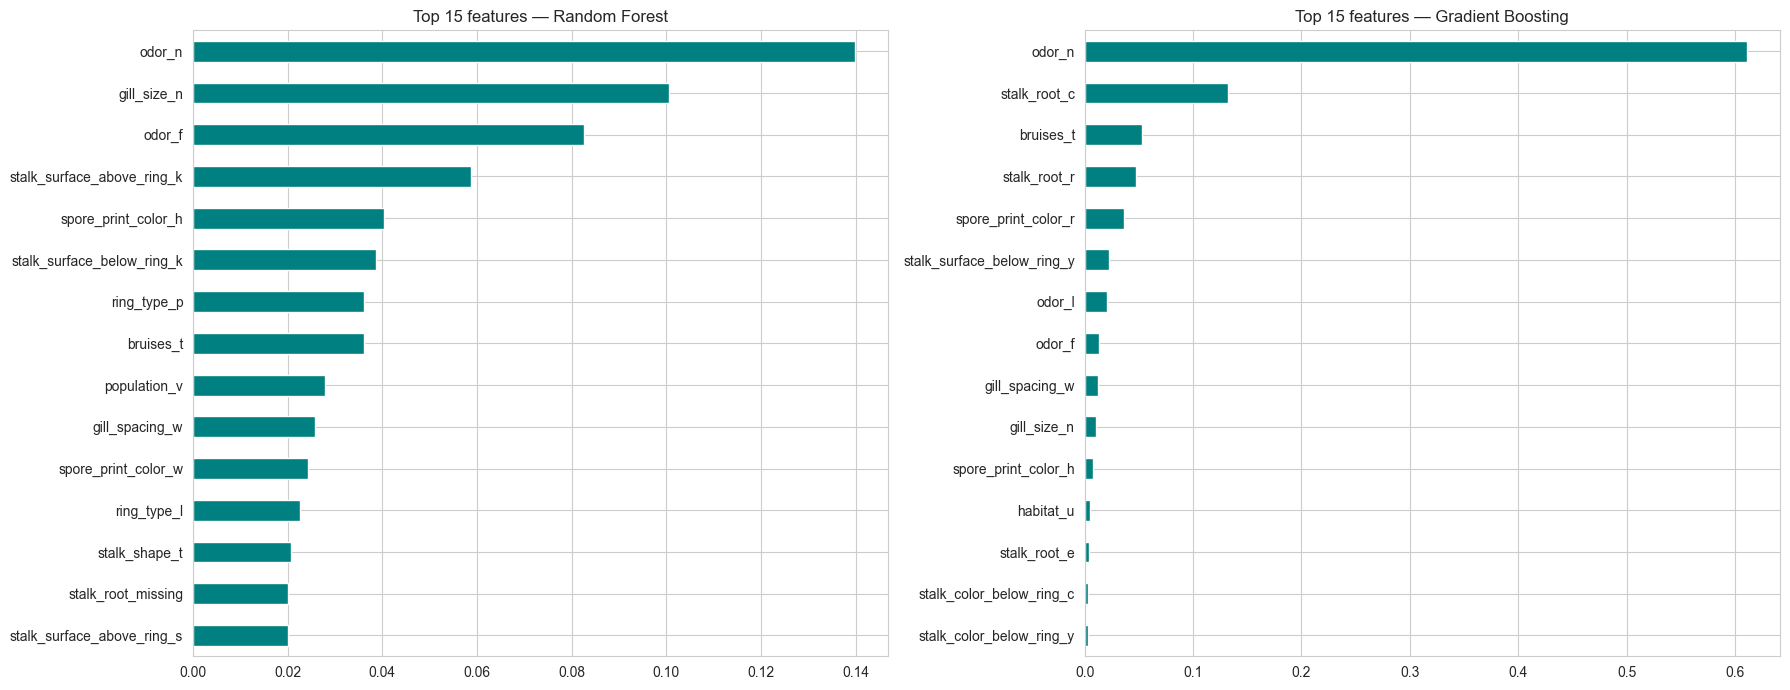

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 15 features — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000
3,KNN (K=1),1.0000,1.0000,1.0000,1.0000
4,SVM,0.9988,1.0000,0.9974,0.9987
5,Gradient Boosting,0.9988,1.0000,0.9974,0.9987
6,Naive Bayes (Bernoulli),0.9286,0.9883,0.8621,0.9209


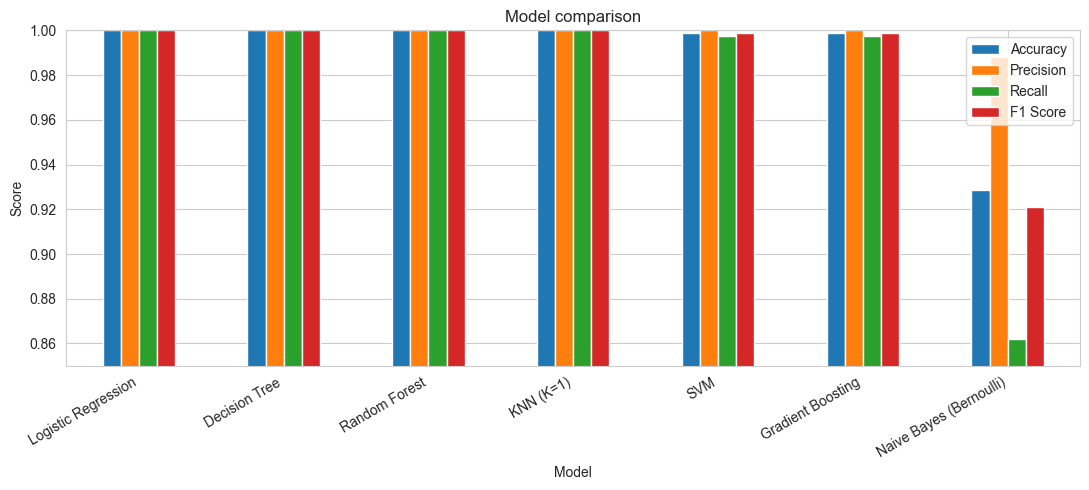

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Model comparison")
ax.set_ylabel("Score"); ax.set_ylim(0.85, 1.0)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Logistic Regression": (lr, X_train_s),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train_s),
    "SVM":                 (svm, X_train_s),
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5)


Logistic Regression
  CV F1 Scores : [0.9984 1.     1.     1.     1.    ]
  Mean F1      : 0.9997 (+/- 0.0006)

Decision Tree
  CV F1 Scores : [0.9984 1.     1.     1.     1.    ]
  Mean F1      : 0.9997 (+/- 0.0006)

Random Forest


  CV F1 Scores : [1. 1. 1. 1. 1.]
  Mean F1      : 1.0000 (+/- 0.0000)

KNN (K=1)
  CV F1 Scores : [0.9984 1.     1.     1.     1.    ]
  Mean F1      : 0.9997 (+/- 0.0006)

SVM


  CV F1 Scores : [0.9976 1.     1.     1.     1.    ]
  Mean F1      : 0.9995 (+/- 0.0010)

Gradient Boosting


  CV F1 Scores : [0.9984 1.     1.     1.     1.    ]
  Mean F1      : 0.9997 (+/- 0.0006)

Naive Bayes
  CV F1 Scores : [0.9213 0.9337 0.9254 0.9362 0.9337]
  Mean F1      : 0.9301 (+/- 0.0057)


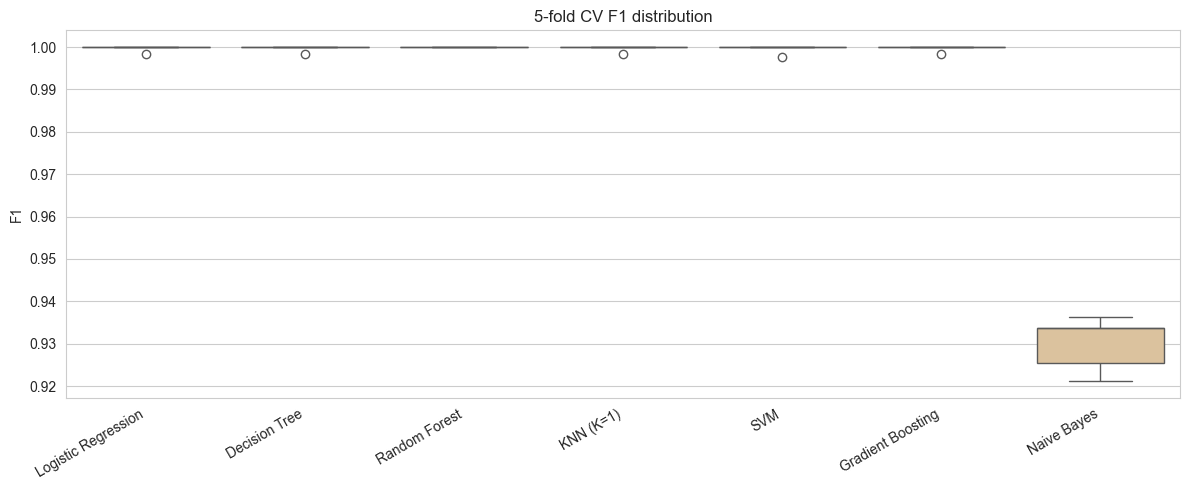

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV F1 distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1")
plt.tight_layout(); plt.show()

## 13. ROC Curves

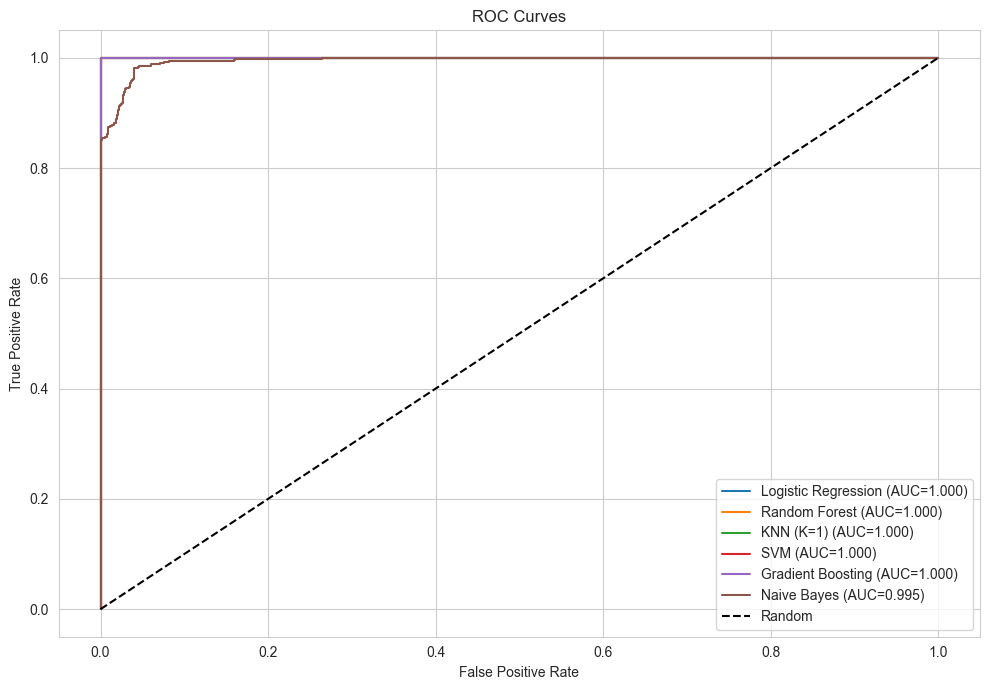

In [16]:
models_for_roc = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    f"KNN (K={best_k})":   knn,
    "SVM":                 svm,
    "Gradient Boosting":   gb,
    "Naive Bayes":         nb,
}
plt.figure(figsize=(10, 7))
for name, m in models_for_roc.items():
    X_in = X_test_s if name in {"Logistic Regression", f"KNN (K={best_k})", "SVM"} else X_test
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_in)[:, 1]
    else:
        y_prob = m.decision_function(X_in)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 14. Hyperparameter Tuning — Random Forest

The baseline already nears perfection on this dataset, so tuning largely confirms a small forest is enough.

In [17]:
param_grid = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [None, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

Best params : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV F1  : 1.0000



  Random Forest (Tuned)
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000


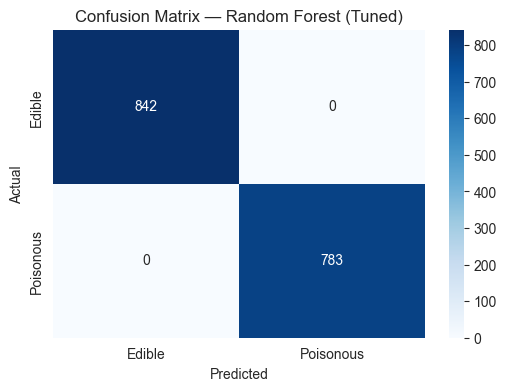

In [18]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)"); plt.show()

## 15. Tuned Feature Importance

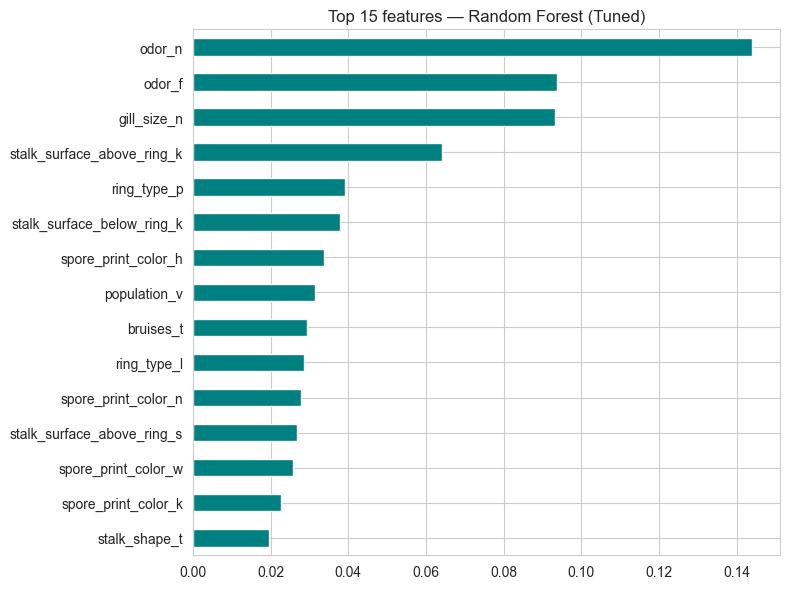

In [19]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
imp.tail(15).plot(kind="barh", color="teal")
plt.title("Top 15 features — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 16. Prediction Example

In [20]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
probs = rf_tuned.predict_proba(sample)[:, 1]
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = "Poisonous" if y_test.loc[idx] else "Edible"
    pred   = "Poisonous" if preds[i] else "Edible"
    print(f"Sample {i}: actual={actual:10s}  predicted={pred:10s}  P(poisonous)={probs[i]:.3f}")

Sample 0: actual=Poisonous   predicted=Poisonous   P(poisonous)=1.000
Sample 1: actual=Poisonous   predicted=Poisonous   P(poisonous)=1.000
Sample 2: actual=Edible      predicted=Edible      P(poisonous)=0.000


## 17. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline | Multiple models reach ~100% test accuracy — the task is famously near-deterministic |
| Tuned model | Random Forest tuned via `GridSearchCV` |
| Top features | `odor`, `spore_print_color`, `gill_color`, `ring_type` |
| Class imbalance | Mild (~52/48); standard stratified split is enough |

### Next Steps
- Build a tiny **decision-tree-based rule extractor** — this dataset can be solved by a 4-5 node tree with very high accuracy.
- Test **robustness to mislabeled training data** — small label-flip experiments.
- Try **categorical-native models** (e.g. `CatBoostClassifier`) without the one-hot expansion.
- Build a Streamlit form with all 22 dropdowns to demo the model on user input.